In [68]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


In [69]:
# Load shapefile provinsi
gdf = gpd.read_file("C:/Uner/Semester 4/Analisis Data Spasial/UTS/gadm41_IDN_1.shp")

# Load data PDB per kapita
pdb_df = pd.read_excel("C:/Uner/Lomba/Smatic/Dataset/Produk Domestik Regional Bruto per Kapita Atas Dasar Harga Berlaku Menurut Provinsi (ribu rupiah), 2023.xlsx")

# Tampilkan kolom untuk pengecekan
print(pdb_df.columns)


Index(['Provinsi', 'Produk Domestik Regional Bruto per Kapita HB (Ribu Rp)'], dtype='object')


In [ ]:
print("Kolom di gdf:", gdf.columns.tolist())
print("Kolom di pdb_df:", pdb_df.columns.tolist())

Kolom di gdf: ['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1', 'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry']
Kolom di pdb_df: ['Provinsi', 'Produk Domestik Regional Bruto per Kapita HB (Ribu Rp)']


In [ ]:
gdf["provinsi"] = gdf["NAME_1"].str.lower().str.strip()
pdb_df["provinsi"] = pdb_df["Provinsi"].str.lower().str.strip()


In [72]:
# Pastikan kolom tersedia
print("Kolom di gdf:", gdf.columns)
print("Kolom di pdb_df:", pdb_df.columns)

# Coba lihat apakah ada kolom mirip "NAME_1"
# Misalnya, jika ternyata kolom adalah "Name_1" (dengan kapitalisasi berbeda), ubah jadi:
gdf["provinsi"] = gdf["NAME_1"].str.lower().str.strip()


Kolom di gdf: Index(['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1',
       'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry',
       'provinsi'],
      dtype='object')
Kolom di pdb_df: Index(['Provinsi', 'Produk Domestik Regional Bruto per Kapita HB (Ribu Rp)',
       'provinsi'],
      dtype='object')


In [73]:
# Cek provinsi yang tidak cocok
provinsi_gdf = set(gdf["provinsi"])
provinsi_pdb = set(pdb_df["provinsi"])

provinsi_tidak_terhubung = provinsi_pdb - provinsi_gdf
print("Provinsi di data PDRB yang tidak cocok dengan shapefile:", provinsi_tidak_terhubung)

provinsi_tidak_masuk_shp = provinsi_gdf - provinsi_pdb
print("Provinsi di shapefile yang tidak cocok dengan data PDRB:", provinsi_tidak_terhubung)


Provinsi di data PDRB yang tidak cocok dengan shapefile: {'papua selatan', 'papua pegunungan', 'papua barat daya', 'papua tengah'}
Provinsi di shapefile yang tidak cocok dengan data PDRB: {'papua selatan', 'papua pegunungan', 'papua barat daya', 'papua tengah'}


In [74]:
import re

def normalisasi_nama_provinsi(nama):
    if pd.isna(nama):
        return ""
    nama = nama.lower()
    nama = re.sub(r'[^a-z0-9 ]', '', nama)  # hilangkan karakter selain huruf, angka, spasi
    nama = re.sub(r'\s+', ' ', nama)        # ganti spasi ganda/tab/newline jadi 1 spasi
    return nama.strip()


In [75]:
gdf["provinsi"] = gdf["provinsi"].apply(normalisasi_nama_provinsi)
pdb_df["provinsi"] = pdb_df["provinsi"].apply(normalisasi_nama_provinsi)


In [76]:
merged = gdf.merge(pdb_df, on="provinsi", how="left")


In [77]:
print("Provinsi tidak punya data PDRB:")
print(merged[merged['Produk Domestik Regional Bruto per Kapita HB (Ribu Rp)'].isna()][['provinsi']])


Provinsi tidak punya data PDRB:
Empty DataFrame
Columns: [provinsi]
Index: []


In [78]:
colors = ["#FC6840", "#EC2C5D"]
cmap = LinearSegmentedColormap.from_list("custom", colors, N=256)


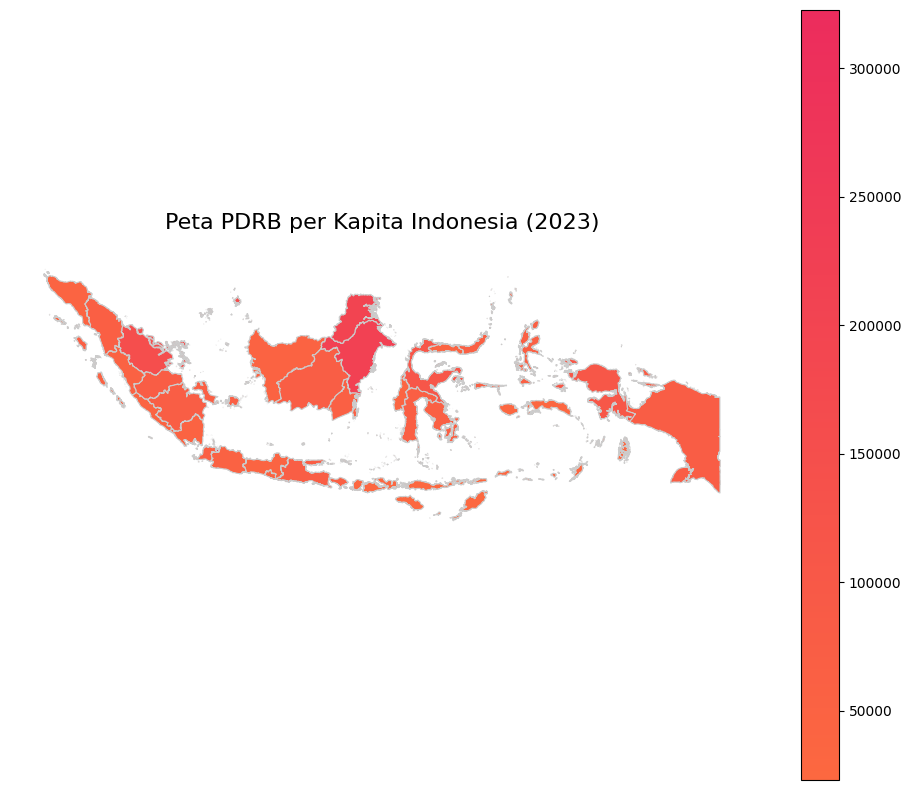

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

merged.plot(column="Produk Domestik Regional Bruto per Kapita HB (Ribu Rp)",
            cmap=cmap,
            linewidth=0.8,
            edgecolor='0.8',
            legend=True,
            ax=ax)

# Hiasan Peta
ax.set_title("Peta PDRB per Kapita Indonesia (2023)",
             fontdict={'fontsize': 16},
             pad=20)
ax.axis('off')

plt.show()


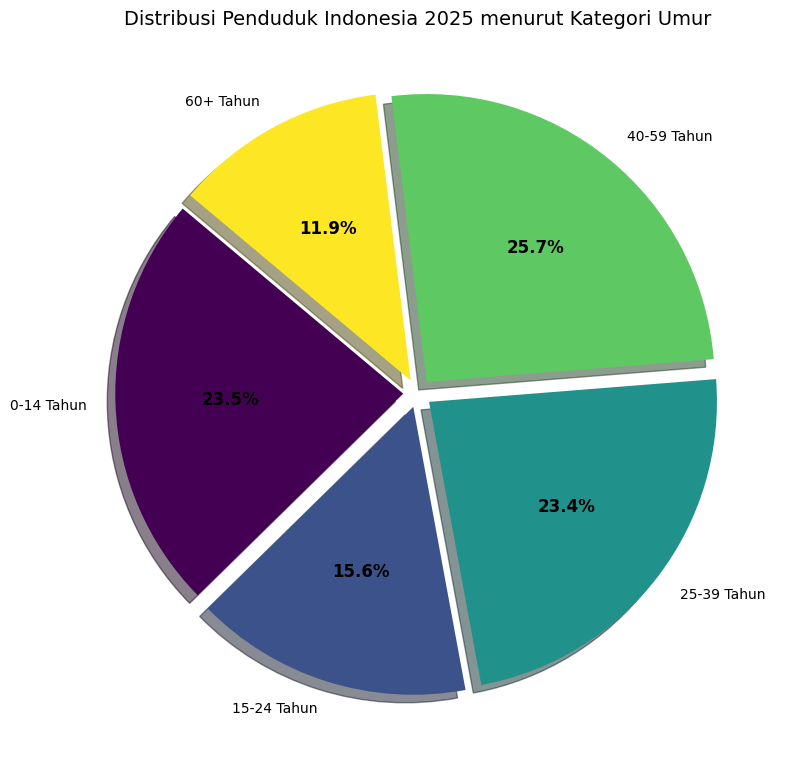

In [80]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

df = pd.read_excel("C:/Uner/Lomba/Smatic/Dataset/Jumlah Penduduk Menurut Kelompok Umur dan Jenis Kelamin, 2025.xlsx")

# Bersihkan nama kelompok umur
df['Kelompok Umur'] = df['Kelompok Umur'].astype(str).str.replace(r"[^\d\-+]", "", regex=True)

# Buat mapping kategori umur
kategori_umur = {
    '0-14 Tahun': ['0-4', '5-9', '10-14'],
    '15-24 Tahun': ['15-19', '20-24'],
    '25-39 Tahun': ['25-29', '30-34', '35-39'],
    '40-59 Tahun': ['40-44', '45-49', '50-54', '55-59'],
    '60+ Tahun': ['60-64', '65-69', '70-74', '75+']
}

# Buat kolom kategori umur berdasarkan mapping
def map_kategori(umur):
    for kategori, kelompok in kategori_umur.items():
        if umur in kelompok:
            return kategori
    return None

df['Kategori Umur'] = df['Kelompok Umur'].apply(map_kategori)

# Hitung total penduduk per kategori umur
kategori_totals = df.groupby('Kategori Umur')['Penduduk (Laki-Laki + Perempuan) (Ribu)'].sum().dropna()

# Pie chart dengan efek 3D semi (menggunakan shadow dan explode)
colors = plt.cm.viridis(np.linspace(0, 1, len(kategori_totals)))
explode = [0.05] * len(kategori_totals)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(aspect="equal"))
wedges, texts, autotexts = ax.pie(
    kategori_totals,
    labels=kategori_totals.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True
)

plt.setp(autotexts, size=12, weight="bold")
ax.set_title("Distribusi Penduduk Indonesia 2025 menurut Kategori Umur", fontsize=14)
plt.tight_layout()
plt.show()

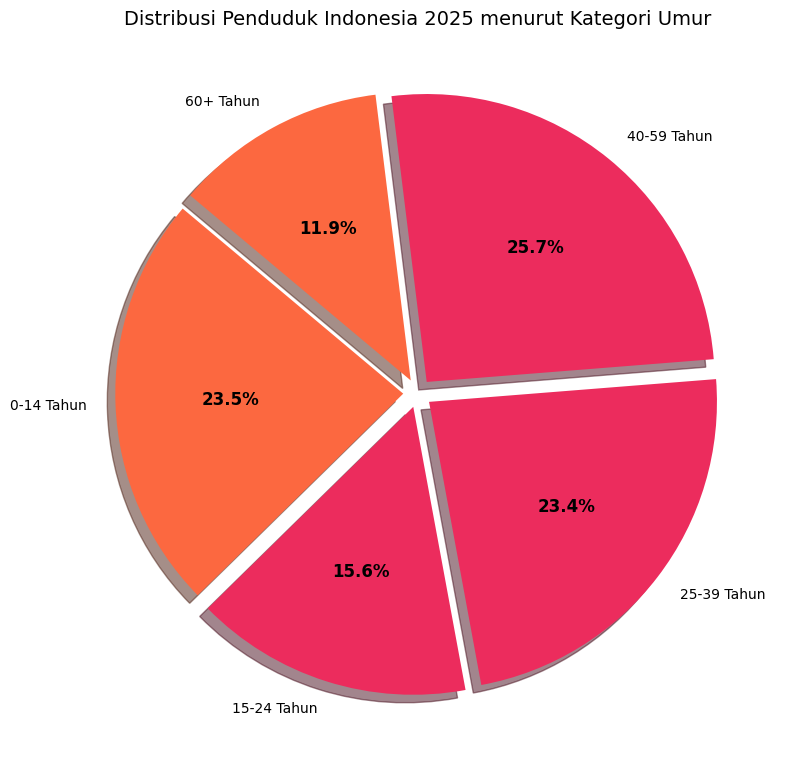

In [81]:
# Mapping kategori umur
kategori_umur = {
    '0-14 Tahun': ['0-4', '5-9', '10-14'],
    '15-24 Tahun': ['15-19', '20-24'],
    '25-39 Tahun': ['25-29', '30-34', '35-39'],
    '40-59 Tahun': ['40-44', '45-49', '50-54', '55-59'],
    '60+ Tahun': ['60-64', '65-69', '70-74', '75+']
}

def map_kategori(umur):
    for kategori, kelompok in kategori_umur.items():
        if umur in kelompok:
            return kategori
    return None

df['Kategori Umur'] = df['Kelompok Umur'].apply(map_kategori)

# Hitung total penduduk per kategori umur
kategori_totals = df.groupby('Kategori Umur')['Penduduk (Laki-Laki + Perempuan) (Ribu)'].sum().dropna()

# Tentukan warna: merah (#EC2C5D) untuk 15–64 tahun, oranye (#FC6840) untuk sisanya
warna_khusus = {
    '0-14 Tahun': '#FC6840',
    '15-24 Tahun': '#EC2C5D',
    '25-39 Tahun': '#EC2C5D',
    '40-59 Tahun': '#EC2C5D',
    '60+ Tahun': '#FC6840'
}
colors = [warna_khusus[k] for k in kategori_totals.index]

explode = [0.05] * len(kategori_totals)

# Buat pie chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(aspect="equal"))
wedges, texts, autotexts = ax.pie(
    kategori_totals,
    labels=kategori_totals.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True
)

plt.setp(autotexts, size=12, weight="bold")
ax.set_title("Distribusi Penduduk Indonesia 2025 menurut Kategori Umur", fontsize=14)
plt.tight_layout()
plt.show()

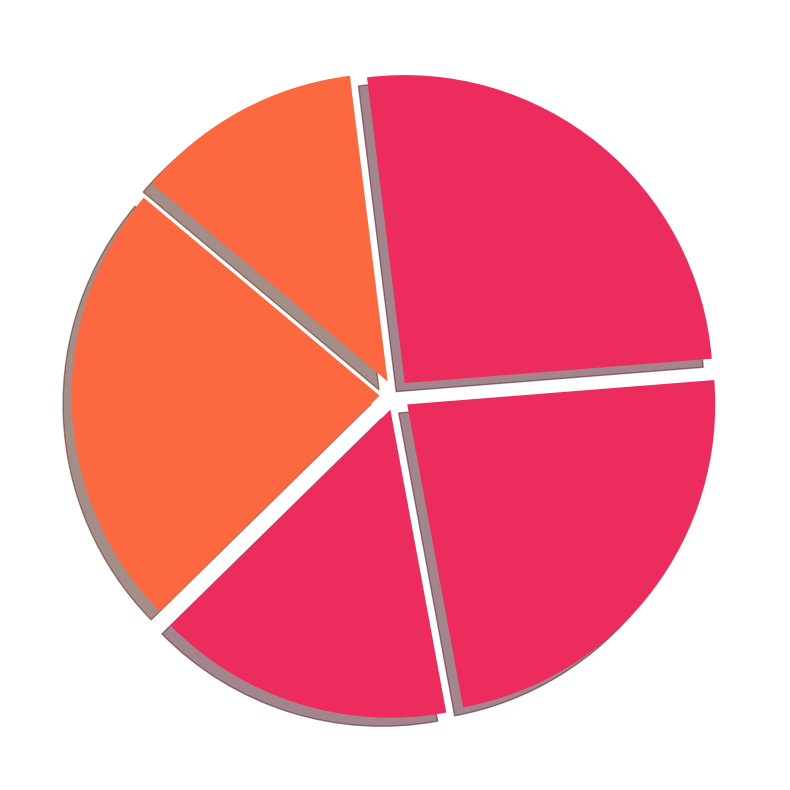

In [83]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(aspect="equal"))
wedges, texts = ax.pie(
    kategori_totals,
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True
)

# Hilangkan axis, title, dan layout tambahan
ax.set_title("")
ax.axis("off")
plt.tight_layout()
plt.show()


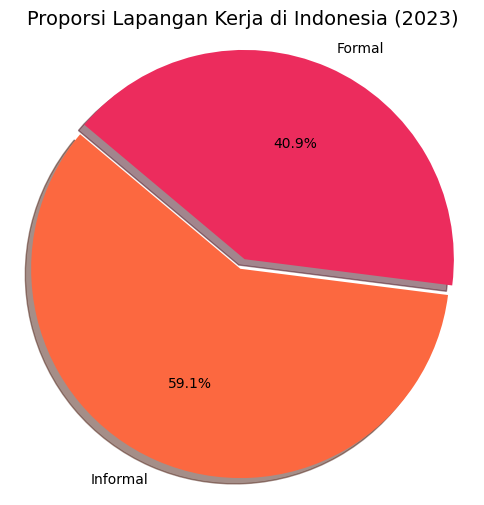

In [88]:
# Data
labels = ['Informal', 'Formal']
sizes = [59.11, 40.89]
colors = ['#FC6840', '#EC2C5D']
explode = (0.05, 0)


plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=140,
    autopct='%1.1f%%'
)
plt.title('Proporsi Lapangan Kerja di Indonesia (2023)', fontsize=14)
plt.axis('equal')
plt.show()

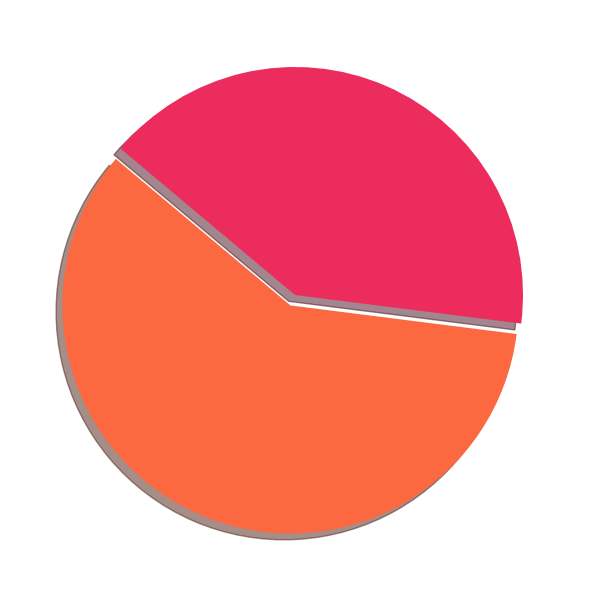

In [85]:
# Data
sizes = [59.11, 40.89]
colors = ['#FC6840', '#EC2C5D']
explode = (0.05, 0)

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=140
)

# Hilangkan title dan sumbu
plt.axis('off')
plt.tight_layout()
plt.show()

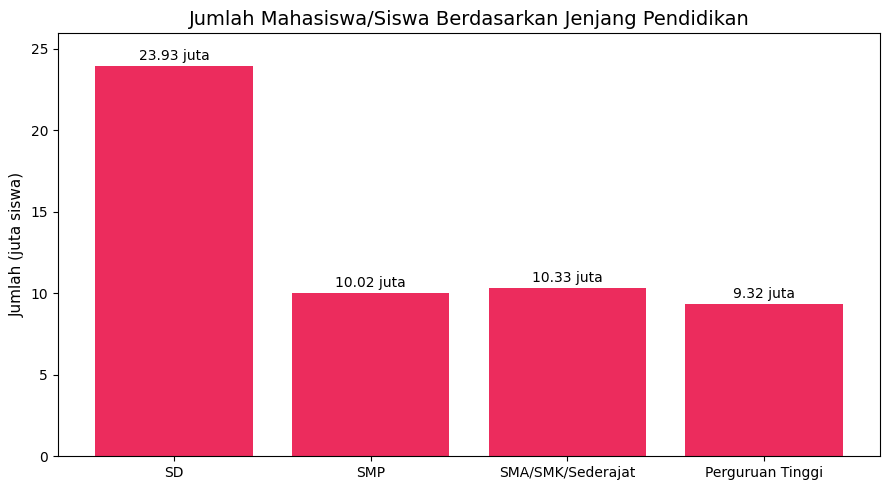

In [ ]:
# Data (dalam satuan juta)
levels = ['SD', 'SMP', 'SMA/SMK/Sederajat', 'Perguruan Tinggi']
values = [
    23933452 / 1_000_000,
    10019185 / 1_000_000,
    (5358915 + 4972749) / 1_000_000,
    9.32
]

# Bulatkan dua angka di belakang koma
values = [round(val, 2) for val in values]

plt.figure(figsize=(9,5))
bars = plt.bar(levels, values, color='#EC2C5D')

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{val:.2f} juta',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Jumlah Mahasiswa/Siswa Berdasarkan Jenjang Pendidikan', fontsize=14)
plt.ylabel('Jumlah (juta siswa)', fontsize=11)
plt.ylim(0, max(values) + 2)
plt.tight_layout()
plt.show()


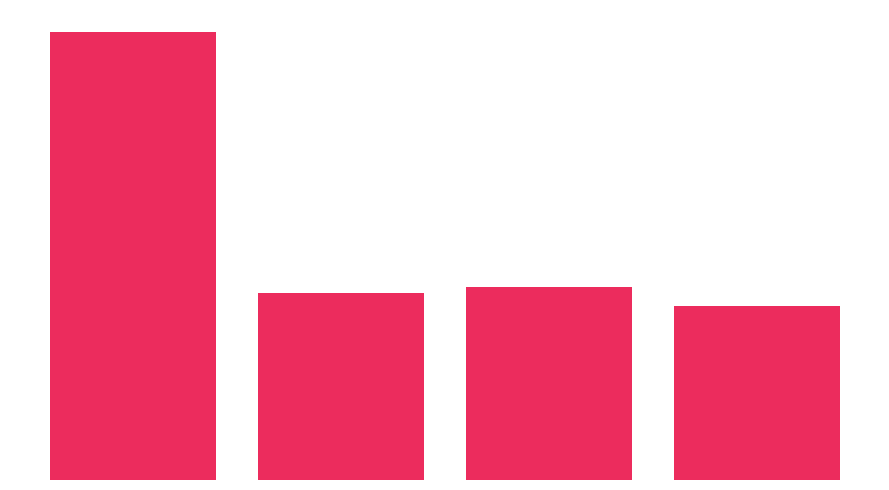

In [87]:
import matplotlib.pyplot as plt

# Data (dalam satuan juta)
levels = ['SD', 'SMP', 'SMA/SMK/Sederajat', 'Perguruan Tinggi']
values = [
    23933452 / 1_000_000,
    10019185 / 1_000_000,
    (5358915 + 4972749) / 1_000_000,
    9.32
]

# Bulatkan dua angka di belakang koma
values = [round(val, 2) for val in values]

plt.figure(figsize=(9,5))
bars = plt.bar(levels, values, color='#EC2C5D')

# Hilangkan ticks dan spines
plt.xticks([])
plt.yticks([])
for spine in ['top', 'right', 'left', 'bottom']:
    plt.gca().spines[spine].set_visible(False)

# Hilangkan axis dan layout
plt.axis('off')
plt.tight_layout()
plt.show()
